In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/My Drive/TX_DATA

/content/drive/My Drive/TX_DATA


In [ ]:
import os
import datetime

import numpy as np
import pandas as pd




In [ ]:
dfs = {}
for index in range(0, 6) :
  df = pd.read_csv('merged_' + str(index + 1) + '.dat', sep=",", parse_dates=["Date"], index_col="Date")
  dfs['Station' + str(index + 1)] = df

In [ ]:
for station, df in dfs.items() :
  print(station)
  print(df.isnull().sum())
  print()

In [ ]:
position_dict = {"Station1": [30.3989,-98.6105],
                 "Station2": [30.4193,-98.8046],
                 "Station3": [30.4421,-98.8427],
                 "Station4": [30.4600, -98.9407],
                 "Station5": [30.2454,-98.7059],
                 "Station6": [30.2758,-98.7242]
                 }

for key in dfs.keys():
  dfs[key]["Latitude"] = position_dict[key][0]
  dfs[key]["Longitude"] = position_dict[key][1]

In [ ]:
training_dfs = []

target_label = 'SWC_50'

for station, df in dfs.items():
  new_df = df.copy()
  new_df = new_df[~new_df[target_label].isnull()]
  training_dfs.append(new_df)

training_dfs.pop(3)

In [ ]:
for df in training_dfs:
  df.dropna(inplace = True)

In [ ]:
for df in training_dfs:
  print(len(df))
  print(df.isnull().sum())

In [ ]:

def target_data_split(frame):
  df = frame.copy().reset_index()
  target = df['SWC_50'].values
  x_data = df[['SWC_5', 'SWC_10', 'SWC_20','Ppt_x']].values
  return (target, x_data)



In [ ]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

LinModel = LinearRegression(fit_intercept=True)


In [ ]:

for df in training_dfs:
  y,x = target_data_split(df)
  LinModel.fit(x,y)


In [ ]:
df4 = dfs["Station4"].copy()
df4.drop(columns = ['SWC_50'], axis = 1, inplace = True)
df4 = df4[['SWC_5', 'SWC_10', 'SWC_20', 'Ppt_x']]
df4.dropna(inplace = True)

In [ ]:
from sklearn.metrics import mean_squared_error


pred = LinModel.predict(df4.values)




In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')


<ipython-input-33-444997ff90a3>:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


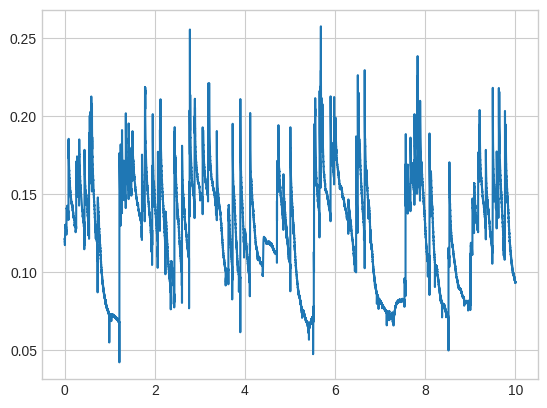

In [ ]:
fig = plt.figure()
ax = plt.axes()

x = np.linspace(0,10,len(pred))
ax.plot(x, pred);

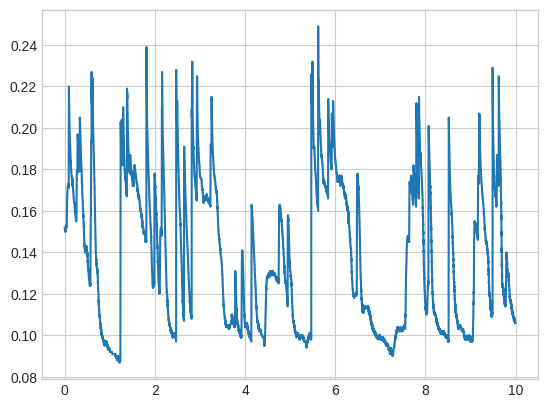

In [ ]:
vals = training_dfs[0]["SWC_50"]

fig = plt.figure()
ax = plt.axes()

x = np.linspace(0,10,len(vals))
ax.plot(x, vals);

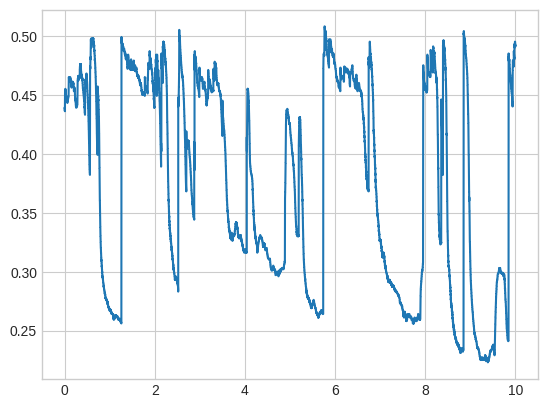

In [ ]:
vals = training_dfs[1]["SWC_50"]

fig = plt.figure()
ax = plt.axes()

x = np.linspace(0,10,len(vals))
ax.plot(x, vals);

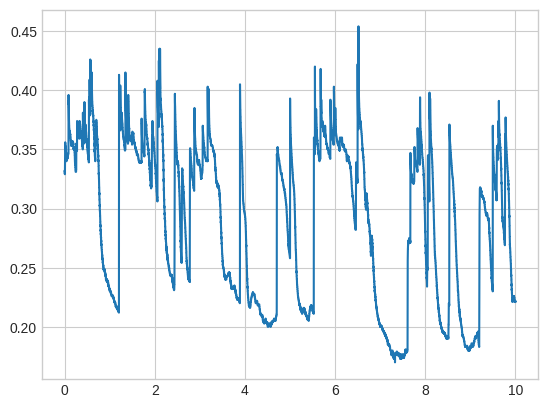

In [ ]:
vals = training_dfs[2]["SWC_50"]

fig = plt.figure()
ax = plt.axes()

x = np.linspace(0,10,len(vals))
ax.plot(x, vals);

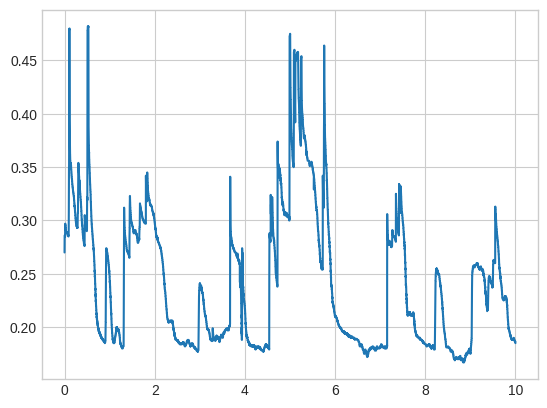

In [ ]:
vals = training_dfs[3]["SWC_50"]

fig = plt.figure()
ax = plt.axes()

x = np.linspace(0,10,len(vals))
ax.plot(x, vals);

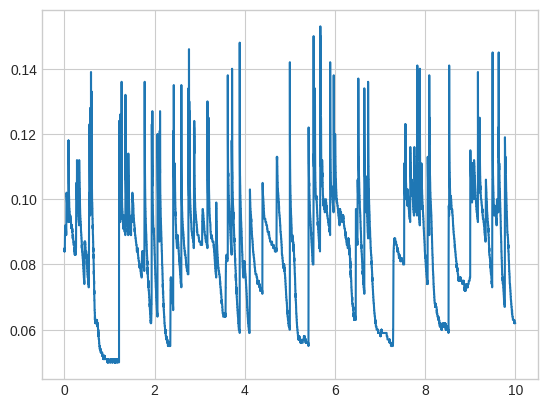

In [ ]:
vals = training_dfs[4]["SWC_50"]

fig = plt.figure()
ax = plt.axes()

x = np.linspace(0,10,len(vals))
ax.plot(x, vals);